<h1>Module 3 - Text Classification with Encoder Models</h1>
<i>Three encoder-classification workflows</i>

- **Part 1:** three-class sentiment classification of solar-energy tweets
- **Part 2:** binary sentiment classification of movie reviews
- **Part 3:** compare DistilBERT and RoBERTa on four-class news classification


## **Learning objectives**

By the end of this notebook, you should be able to:

- load and inspect labeled text data for binary and multiclass classification;
- use Hugging Face pipelines with task-specific encoder models;
- organize model outputs as predicted labels, probabilities, and confidence scores;
- evaluate predictions using precision, recall, F1, and confusion matrices;
- analyze confident errors and disagreements between models; and
- compare encoder models using both predictive performance and inference time.


### Optional: install packages in Google Colab

Uncomment and run the next cell if the packages are missing. For faster
inference, choose **Runtime → Change runtime type → T4 GPU**.


In [ ]:
# %pip install -q datasets pandas matplotlib scikit-learn transformers torch


In [ ]:
from google.colab import drive
drive.mount("/content/drive")


# **Part 1: Solar Tweet Classification**

Each row is one solar-energy tweet. `category` is its negative, neutral, or
positive sentiment label.


Note: [Code for Fine-Tuning RoBERTa](https://github.com/SerenaYKim/Solar-Sentiment-BERT/blob/master/04_BERT.ipynb)

In [ ]:
import pandas as pd

solar_data = pd.read_csv(
    "data/Module03/solar-energy-messages-sample.csv",
    dtype={"tweet_id": "string"},
    lineterminator="\n",
)

solar_data["category"] = solar_data["category"].str.lower()
solar_data.head()


## **Solar Sentiment Encoder**

`serenakim/solar-sentiment` is a RoBERTa encoder fine-tuned for negative,
neutral, and positive solar-energy sentiment.


In [ ]:
import torch
from transformers import pipeline

DEVICE = 0 if torch.cuda.is_available() else -1
BATCH_SIZE = 32 if torch.cuda.is_available() else 8

print(f"Using {'GPU' if DEVICE == 0 else 'CPU'}")

In [ ]:
SOLAR_MODEL = "serenakim/solar-sentiment"

solar_classifier = pipeline(
    "text-classification",
    model=SOLAR_MODEL,
    tokenizer=SOLAR_MODEL,
    device=DEVICE,
)

In [ ]:
SOLAR_LABELS = ["positive", "neutral", "negative"]

raw_solar_predictions = solar_classifier(
    solar_data["text"].tolist(),
    batch_size=BATCH_SIZE,
    truncation=True,
    padding=True,
    max_length=256,
    top_k=None,
)

solar_probabilities = pd.DataFrame([
    {item["label"].lower(): item["score"] for item in result}
    for result in raw_solar_predictions
])

solar_data["prediction"] = solar_probabilities.idxmax(axis=1)
solar_data["confidence"] = solar_probabilities.max(axis=1)
solar_data[[f"prob_{label}" for label in SOLAR_LABELS]] = (
    solar_probabilities[SOLAR_LABELS].to_numpy()
)

solar_data[[
    "text",
    "category",
    "prediction",
    "confidence",
    "prob_positive",
    "prob_neutral",
    "prob_negative",
]].head(8)


## **Evaluation**

The classification report shows precision, recall, and F1 for each class.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

solar_y_true = solar_data["category"]
solar_y_pred = solar_data["prediction"]

print(classification_report(
    solar_y_true,
    solar_y_pred,
    labels=SOLAR_LABELS,
    target_names=SOLAR_LABELS,
    digits=3,
    zero_division=0,
))

ConfusionMatrixDisplay.from_predictions(
    solar_y_true,
    solar_y_pred,
    labels=SOLAR_LABELS,
    display_labels=SOLAR_LABELS,
    cmap="Blues",
    colorbar=False,
)
plt.title("Solar sentiment classification")
plt.grid(False)
plt.show()


In [ ]:
solar_errors = solar_data[
    solar_data["category"] != solar_data["prediction"]
].sort_values("confidence", ascending=False)

solar_errors[[
    "text", "category", "prediction", "confidence"
]].head(12)


### **Your turn**

1. Which class has the lowest recall?
2. Why is macro-F1 lower than weighted F1?
3. Inspect three confident errors. What makes each tweet difficult?


# **Part 2: Movie Review Classification**

The Rotten Tomatoes dataset contains short movie reviews labeled negative (`0`)
or positive (`1`). We will evaluate a second task-specific encoder on its test set.


In [ ]:
import torch
from transformers import pipeline

DEVICE = 0 if torch.cuda.is_available() else -1
BATCH_SIZE = 32 if torch.cuda.is_available() else 8

print(f"Using {'GPU' if DEVICE == 0 else 'CPU'}")

Using GPU


In [ ]:
from datasets import load_dataset

movie_data = load_dataset("cornell-movie-review-data/rotten_tomatoes") #https://huggingface.co/datasets/cornell-movie-review-data/rotten_tomatoes
movie_test = movie_data["test"].to_pandas()
movie_test["category"] = movie_test["label"].map({0: "negative", 1: "positive"})
movie_test.head()


,text,label,category
0,lovingly photographed in the manner of a golde...,1,positive
1,consistently clever and suspenseful .,1,positive
2,"it's like a "" big chill "" reunion of the baade...",1,positive
3,the story gives ample opportunity for large-sc...,1,positive
4,"red dragon "" never cuts corners .",1,positive


## **Movie Sentiment Encoder**

[`distilbert-base-uncased-finetuned-sst-2-english`](https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english)
is a DistilBERT encoder fine-tuned for negative and positive movie sentiment.


In [ ]:
import torch
from transformers import pipeline

MOVIE_MODEL = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"

movie_classifier = pipeline(
    "text-classification",
    model=MOVIE_MODEL,
    tokenizer=MOVIE_MODEL,
    device=DEVICE,
)


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

In [ ]:
import pandas as pd

example_review = movie_test.loc[3, "text"]
example_scores = movie_classifier(
    example_review, truncation=True, max_length=256, top_k=None
)

print(example_review)
pd.DataFrame(example_scores).sort_values("score", ascending=False)


the story gives ample opportunity for large-scale action and suspense , which director shekhar kapur supplies with tremendous skill .


,label,score
0,POSITIVE,0.999874
1,NEGATIVE,0.000126


In [ ]:
MOVIE_LABELS = ["positive", "negative"]

raw_movie_predictions = movie_classifier(
    movie_test["text"].tolist(),
    batch_size=BATCH_SIZE,
    truncation=True,
    padding=True,
    max_length=256,
    top_k=None,
)

movie_probabilities = pd.DataFrame([
    {item["label"].lower(): item["score"] for item in result}
    for result in raw_movie_predictions
])

movie_test["prediction"] = movie_probabilities.idxmax(axis=1)
movie_test["confidence"] = movie_probabilities.max(axis=1)
movie_test[[f"prob_{label}" for label in MOVIE_LABELS]] = (
    movie_probabilities[MOVIE_LABELS].to_numpy()
)

movie_test[[
    "text",
    "category",
    "prediction",
    "confidence",
    "prob_positive",
    "prob_negative",
]].head(8)


,text,category,prediction,confidence,prob_positive,prob_negative
0,lovingly photographed in the manner of a golde...,positive,positive,0.999815,0.999815,0.000185
1,consistently clever and suspenseful .,positive,positive,0.999882,0.999882,0.000118
2,"it's like a "" big chill "" reunion of the baade...",positive,negative,0.990973,0.009027,0.990973
3,the story gives ample opportunity for large-sc...,positive,positive,0.999874,0.999874,0.000126
4,"red dragon "" never cuts corners .",positive,positive,0.999581,0.999581,0.000419
5,fresnadillo has something serious to say about...,positive,positive,0.999247,0.999247,0.000753
6,throws in enough clever and unexpected twists ...,positive,positive,0.999796,0.999796,0.000204
7,weighty and ponderous but every bit as filling...,positive,positive,0.999665,0.999665,0.000335


## **Evaluation**


              precision    recall  f1-score   support

    positive      0.901     0.891     0.896       533
    negative      0.892     0.902     0.897       533

    accuracy                          0.897      1066
   macro avg      0.897     0.897     0.897      1066
weighted avg      0.897     0.897     0.897      1066



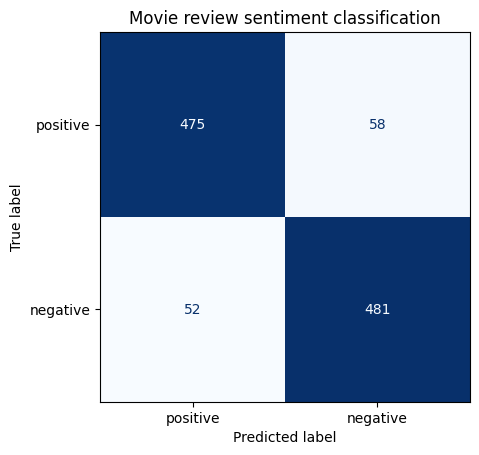

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

movie_y_true = movie_test["category"]
movie_y_pred = movie_test["prediction"]

print(classification_report(
    movie_y_true,
    movie_y_pred,
    labels=MOVIE_LABELS,
    target_names=MOVIE_LABELS,
    digits=3,
    zero_division=0,
))

ConfusionMatrixDisplay.from_predictions(
    movie_y_true,
    movie_y_pred,
    labels=MOVIE_LABELS,
    display_labels=MOVIE_LABELS,
    cmap="Blues",
    colorbar=False,
)
plt.title("Movie review sentiment classification")
plt.grid(False)
plt.show()


In [ ]:
movie_errors = movie_test[
    movie_test["category"] != movie_test["prediction"]
].sort_values("confidence", ascending=False)

movie_errors[[
    "text", "category", "prediction", "confidence"
]].head(12)


,text,category,prediction,confidence
633,an encouraging effort from mccrudden,negative,positive,0.999872
725,"never again , while nothing special , is pleas...",negative,positive,0.999864
614,seeing as the film lacks momentum and its posi...,negative,positive,0.999823
332,"i just saw this movie . . . well , it's probab...",positive,negative,0.999803
732,too daft by half . . . but supremely good natu...,negative,positive,0.999796
197,""" . . . something appears to have been lost in...",positive,negative,0.999773
116,you don't know whether to admire the film's st...,positive,negative,0.999767
293,suffers from its timid parsing of the barn-sid...,positive,negative,0.999740
607,though its rather routine script is loaded wit...,negative,positive,0.999710
276,the movie worked for me right up to the final ...,positive,negative,0.999693


### **Your turn**

1. Which movie-review class has the lower recall?
2. Inspect three confident errors. Do they involve negation, mixed sentiment, or
   debatable labels?
3. Why can the two encoder models use the same pipeline code but produce different
   sets of labels?


# **Compare the Two Ready-Made Classifiers**

| Model | Domain | Labels |
|---|---|---|
| Solar RoBERTa | Solar-energy tweets | positive, neutral, negative |
| DistilBERT SST-2 | Movie sentiment | positive, negative |

Both models combine an encoder with a task-specific classification head. Their
available labels and learned decision rules come from different fine-tuning data.


# **Part 3: Compare Two News Classification Models** (TAKE HOME)

In this section, we compare two encoder models—DistilBERT and RoBERTa—on the
same four-category news classification task.

Both models are already fine-tuned on AG News. We will evaluate them using the
same test data and compare their precision, recall, F1 scores, confusion
matrices, and inference times.

### **Setup**

In [ ]:
import torch
from datasets import load_dataset
from transformers import pipeline

DEVICE = 0 if torch.cuda.is_available() else -1
BATCH_SIZE = 32 if torch.cuda.is_available() else 8

### **Load the Data**

In [ ]:
news_data = load_dataset("fancyzhx/ag_news")
news_test = news_data["test"].to_pandas()

NEWS_LABELS = ["World", "Sports", "Business", "Sci/Tech"]
news_test["category"] = news_test["label"].map(
    dict(enumerate(NEWS_LABELS))
)

news_test.head()

,text,label,category
0,Fears for T N pension after talks Unions repre...,2,Business
1,The Race is On: Second Private Team Sets Launc...,3,Sci/Tech
2,Ky. Company Wins Grant to Study Peptides (AP) ...,3,Sci/Tech
3,Prediction Unit Helps Forecast Wildfires (AP) ...,3,Sci/Tech
4,Calif. Aims to Limit Farm-Related Smog (AP) AP...,3,Sci/Tech


### **Load the Two Models**

In [ ]:
DISTILBERT_MODEL = "textattack/distilbert-base-uncased-ag-news"
ROBERTA_MODEL = "textattack/roberta-base-ag-news"

distilbert_classifier = pipeline(
    "text-classification",
    model=DISTILBERT_MODEL,
    device=DEVICE,
)

roberta_classifier = pipeline(
    "text-classification",
    model=ROBERTA_MODEL,
    device=DEVICE,
)

### **Take-home task**

1. Compare the accuracy and macro-F1 of DistilBERT and RoBERTa. Which model performs
   better overall?
2. For each model, which news category has the lowest recall? Use the
   classification reports as evidence.
3. Compare the inference times. How much faster is one model than the other?
4. Inspect five examples where the models disagree. Which model is correct more
   often, and which categories are commonly confused?
5. Based on predictive performance and inference speed, which model would you
   recommend for classifying a large collection of news articles? Explain your
   choice.